In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as mlt 
import seaborn as sb 
import warnings
warnings.filterwarnings('ignore')


In [2]:
df=pd.read_csv('insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# EDA

In [3]:
df.shape

(1338, 7)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

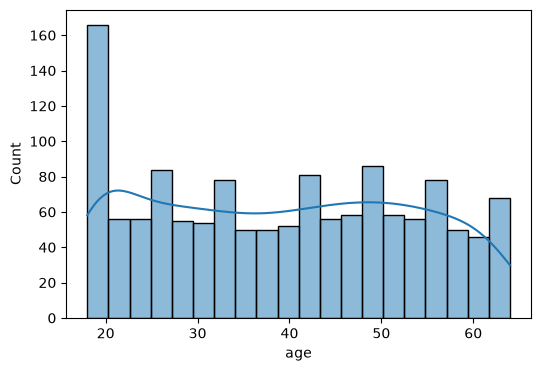

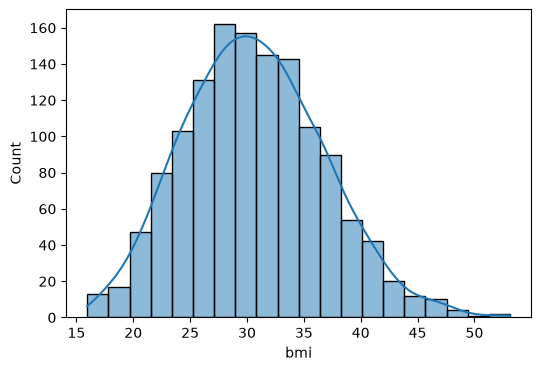

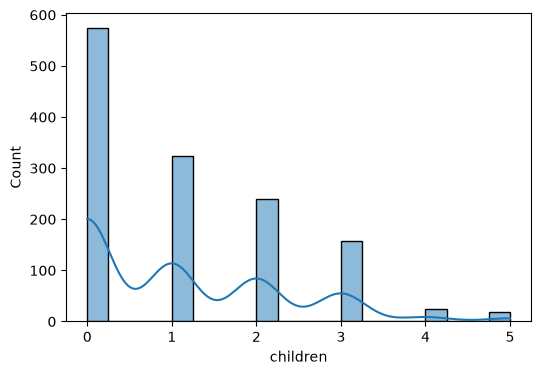

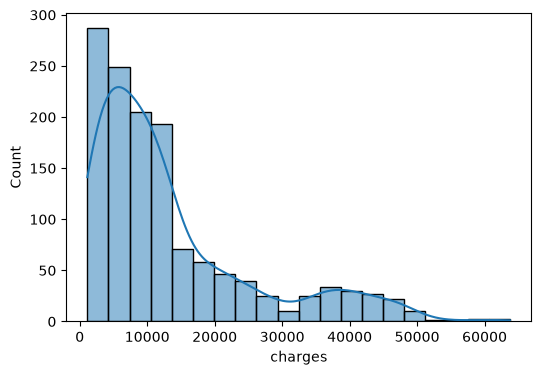

In [7]:
numeric_col=['age', 'bmi', 'children', 'charges']
for col in numeric_col:
    mlt.figure(figsize=(6,4))
    sb.histplot(df[col],kde=True,bins=20)

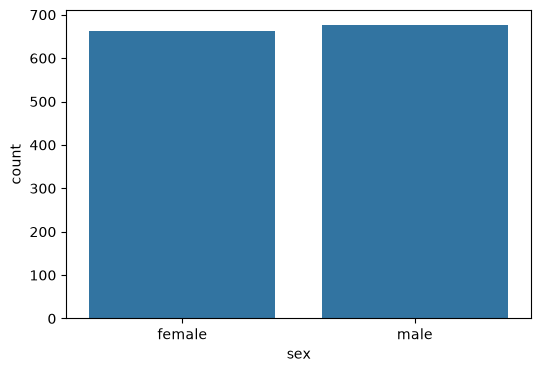

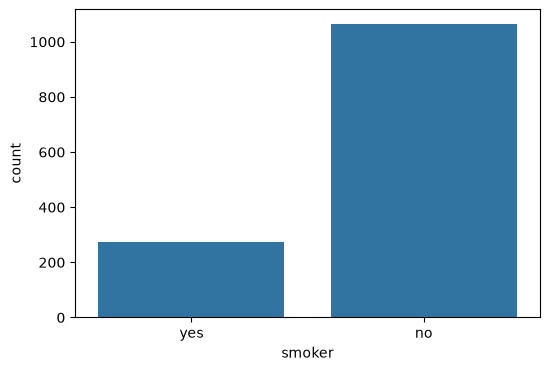

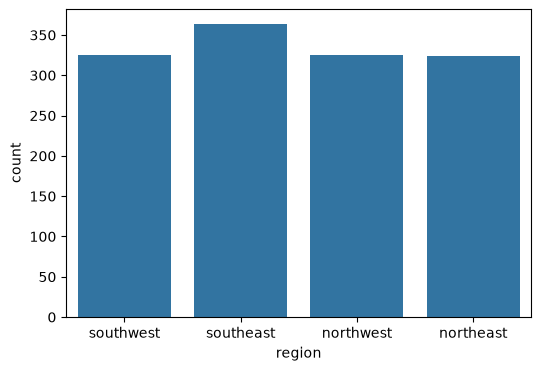

In [8]:
categorical_data=['sex','smoker', 'region']
for col in categorical_data: 
    mlt.figure(figsize=(6,4))
    sb.countplot(x=df[col])

Outliers

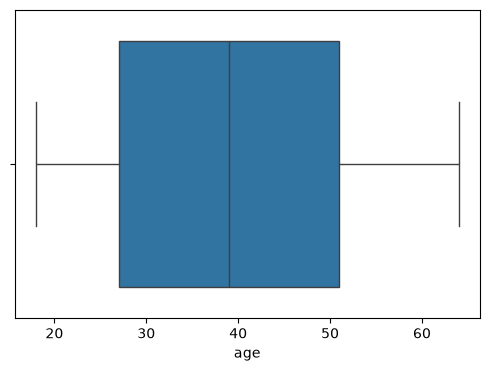

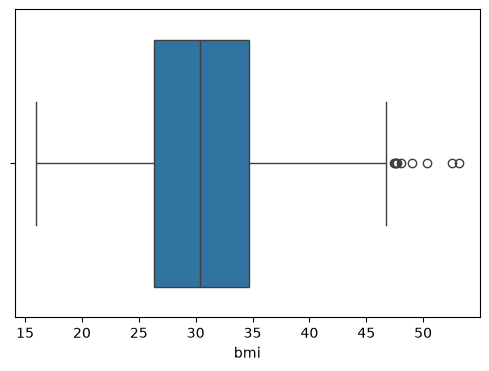

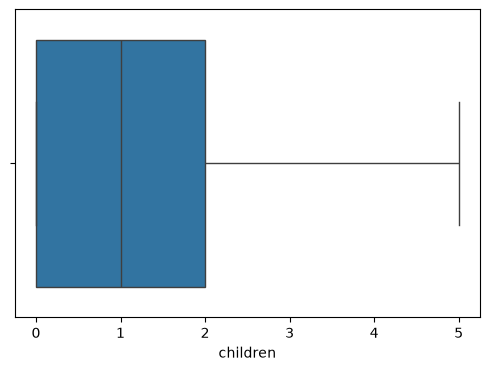

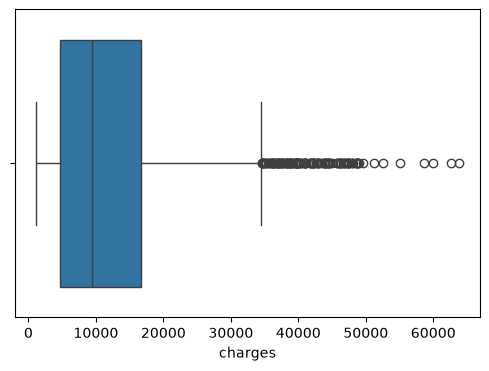

In [9]:
for col in numeric_col: 
    mlt.figure(figsize=(6,4))
    sb.boxplot(x=df[col])

Relations of numeric_value

<Axes: >

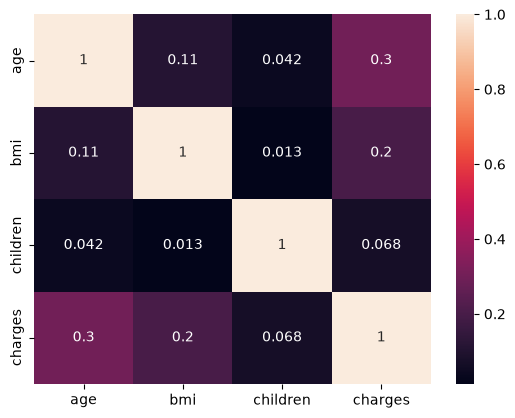

In [10]:
sb.heatmap(df.corr(numeric_only=True),annot=True)

# Data Preprocessing and cleaning

In [11]:
data_cleaned=df.copy()

In [12]:
data_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [13]:
data_cleaned.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [14]:
data_cleaned.drop_duplicates(inplace=True)

In [15]:
data_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [16]:
data_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [17]:
data_cleaned['sex']=data_cleaned['sex'].map({"male":0,"female":1})

In [18]:
data_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [19]:
data_cleaned['smoker']=data_cleaned['smoker'].map({"yes":1,"no":0})

In [20]:
data_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [21]:
data_cleaned.rename(columns={
    "sex":"is_female",
    "smoker": "is_smoker"
},inplace=True)

In [22]:
data_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [23]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [24]:
data_cleaned=pd.get_dummies(data_cleaned,columns=['region'],dtype=int)

In [25]:
data_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,0,0,0,1
1,18,0,33.770,1,0,1725.55230,0,0,1,0
2,28,0,33.000,3,0,4449.46200,0,0,1,0
3,33,0,22.705,0,0,21984.47061,0,1,0,0
4,32,0,28.880,0,0,3866.85520,0,1,0,0


# Feature Enginnering and Extraction

In [26]:
# Extracting the feature from BMI column
data_cleaned['bmi_category']=pd.cut(
    data_cleaned['bmi'],
    bins=[0,18.5,24.9,29.9,float('inf')],
    labels=["Underweight","Normal","Overweight","Obese"]
)

In [27]:
# 2. Encode BMI category ONCE
data_cleaned = pd.get_dummies(
    data_cleaned,
    columns=['bmi_category'],
    dtype=int
)

In [29]:
data_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Underweight,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27.900,0,1,16884.92400,0,0,0,1,0,0,1,0
1,18,0,33.770,1,0,1725.55230,0,0,1,0,0,0,0,1
2,28,0,33.000,3,0,4449.46200,0,0,1,0,0,0,0,1
3,33,0,22.705,0,0,21984.47061,0,1,0,0,0,1,0,0
4,32,0,28.880,0,0,3866.85520,0,1,0,0,0,0,1,0


# Scaling data

In [32]:
from sklearn.preprocessing import StandardScaler #sklearn is the librabry, StandardScaler calculate the mean and standard deviation for the column

col=['age','bmi','children'] # column that we want to scale between 0 & 1
scale=StandardScaler()# Create a machine that knows how to calculate mean and standard deviation and then standardize my data.
data_cleaned[col]=scale.fit_transform(data_cleaned[col])#Standardizes the selected columns by calculating their mean and standard deviation, then transforming them to a standard scale.

In [33]:
data_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Underweight,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,-1.440418,1,-0.453160,-0.909234,1,16884.92400,0,0,0,1,0,0,1,0
1,-1.511647,0,0.509422,-0.079442,0,1725.55230,0,0,1,0,0,0,0,1
2,-0.799350,0,0.383155,1.580143,0,4449.46200,0,0,1,0,0,0,0,1
3,-0.443201,0,-1.305052,-0.909234,0,21984.47061,0,1,0,0,0,1,0,0
4,-0.514431,0,-0.292456,-0.909234,0,3866.85520,0,1,0,0,0,0,1,0


In [44]:
correlation_df=data_cleaned.corr(method='pearson')['charges'].sort_values(ascending=False).drop('charges')
correlation_df = correlation_df.reset_index()
correlation_df.columns = ['feature', 'correlation']
correlation_df

,feature,correlation
0,is_smoker,0.787234
1,age,0.298308
2,bmi,0.198401
3,bmi_category_Obese,0.197659
4,region_southeast,0.073578
5,children,0.067389
6,region_northeast,0.005945
7,region_northwest,-0.038695
8,region_southwest,-0.043637
9,bmi_category_Underweight,-0.048225
